In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')
base_path = "/content/drive/MyDrive/Modelling_Minds"

Mounted at /content/drive


## 1. Load Data

Load the train/test CSVs and fix the target column name (`TARGET`) used throughout the notebook.

In [4]:
train_path = f"{base_path}/track3.csv"
test_path = f"{base_path}/test_pred_ml03.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

TARGET = "start_category"

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

Train shape: (664, 39)
Test shape: (112, 38)


,subject_id,gender,race,arrival_transport,temperature,heartrate,resprate,o2sat,sbp,dbp,...,vs_sbp_max,vs_sbp_mean,vs_o2sat_min,vs_o2sat_max,vs_o2sat_mean,vs_temperature_max,n_vitalsign_readings,n_diagnoses,n_home_meds,start_category
0,90000355,F,UNKNOWN,AMBULANCE,97.9,112.0,28.0,89.0,93.0,46.0,...,89.0,85.5,86.0,88.0,87.0,97.7,2,3,6,YELLOW
1,90000004,F,UNABLE TO OBTAIN,AMBULANCE,97.0,NaN,0.0,57.0,NaN,NaN,...,45.0,45.0,NaN,NaN,NaN,96.5,2,2,7,BLACK
2,90000021,M,HISPANIC/LATINO - CUBAN,AMBULANCE,94.1,0.0,0.0,NaN,NaN,NaN,...,24.0,24.0,NaN,NaN,NaN,96.0,3,1,6,BLACK
3,90000176,F,UNKNOWN,AMBULANCE,NaN,NaN,NaN,NaN,NaN,NaN,...,26.0,26.0,10.0,10.0,10.0,96.7,3,1,10,BLACK
4,90000200,M,WHITE,AMBULANCE,94.5,0.0,0.0,27.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,94.8,1,2,9,BLACK


,subject_id,gender,race,arrival_transport,temperature,heartrate,resprate,o2sat,sbp,dbp,...,vs_sbp_min,vs_sbp_max,vs_sbp_mean,vs_o2sat_min,vs_o2sat_max,vs_o2sat_mean,vs_temperature_max,n_vitalsign_readings,n_diagnoses,n_home_meds
0,90000431,M,PATIENT DECLINED TO ANSWER,AMBULANCE,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,21.000000,42.000000,31.500000,96.200000,2,2,6
1,90000438,F,WHITE - OTHER EUROPEAN,AMBULANCE,93.5,21.0,0.0,35.0,NaN,NaN,...,16.0,26.0,21.0,55.000000,55.000000,55.000000,96.600000,3,2,4
2,90000445,F,PATIENT DECLINED TO ANSWER,AMBULANCE,NaN,NaN,NaN,NaN,NaN,NaN,...,36.0,39.0,37.5,NaN,NaN,NaN,96.600000,3,2,14
3,90000457,F,HISPANIC/LATINO - SALVADORAN,AMBULANCE,93.8,NaN,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,94.275702,1,2,11
4,90000460,F,WHITE,AMBULANCE,95.3,0.0,0.0,43.0,NaN,NaN,...,NaN,NaN,NaN,44.841077,45.819711,45.317784,96.049343,3,3,12


## 2. Data Quality Overview

Check dtype, cardinality, and missingness for every column up front — this decides which
features need categorical encoding vs. numeric handling, and which have enough
missingness to require a strategy.

In [5]:
display(
    pd.DataFrame({
        "Data Type": train_df.dtypes,
        "Unique Values": train_df.nunique(),
        "Missing Values": train_df.isna().sum(),
        "Missing %": (train_df.isna().mean() * 100).round(2)
    }).sort_values("Missing %", ascending=False)
)

categorical_cols = train_df.drop(columns=[TARGET]).select_dtypes(include=["object"]).columns.tolist()
numerical_cols = train_df.drop(columns=[TARGET]).select_dtypes(include=["number"]).columns.tolist()

print(f"\nCategorical columns ({len(categorical_cols)}):", categorical_cols)
print(f"\nNumerical columns ({len(numerical_cols)}):", numerical_cols)

,Data Type,Unique Values,Missing Values,Missing %
pain_score,float64,11,237,35.69
dbp,float64,81,142,21.39
sbp,float64,122,141,21.23
pain_assessable,float64,2,140,21.08
o2sat,float64,54,119,17.92
vs_sbp_min,float64,130,83,12.50
vs_sbp_mean,float64,352,83,12.50
vs_sbp_max,float64,127,83,12.50
temperature,float64,80,82,12.35
heartrate,float64,134,80,12.05



Categorical columns (6): ['gender', 'race', 'arrival_transport', 'avpu', 'consciousness_source', 'chiefcomplaint']

Numerical columns (32): ['subject_id', 'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'bp_unobtainable', 'pain_score', 'pain_assessable', 'gcs_eye', 'gcs_verbal', 'gcs_motor', 'gcs_total', 'avpu_ordinal', 'follows_commands', 'vs_heartrate_min', 'vs_heartrate_max', 'vs_heartrate_mean', 'vs_resprate_min', 'vs_resprate_max', 'vs_resprate_mean', 'vs_sbp_min', 'vs_sbp_max', 'vs_sbp_mean', 'vs_o2sat_min', 'vs_o2sat_max', 'vs_o2sat_mean', 'vs_temperature_max', 'n_vitalsign_readings', 'n_diagnoses', 'n_home_meds']


## 3. Leakage Audit — Are `vs_*` Columns Intake-Only?

`vs_heartrate_*`, `vs_resprate_*`, `vs_sbp_*`, `vs_o2sat_*`, `vs_temperature_max`, and
`n_vitalsign_readings` look like they could be whole-encounter aggregates rather than a
single intake-time snapshot. If so, using them as features means training on information
that didn't exist yet when triage was actually assigned — verify before trusting them.

In [6]:
print("n_vitalsign_readings range:", train_df["n_vitalsign_readings"].min(), "-", train_df["n_vitalsign_readings"].max())

single_reading = train_df[train_df["n_vitalsign_readings"] == 1]
match_rate = (single_reading["heartrate"] == single_reading["vs_heartrate_mean"]).mean()
print(f"Among patients with exactly 1 recorded reading, intake heartrate == vs_heartrate_mean: {match_rate:.1%}")

n_vitalsign_readings range: 0 - 22
Among patients with exactly 1 recorded reading, intake heartrate == vs_heartrate_mean: 5.1%


**Finding:** `n_vitalsign_readings` ranges from 0 to 22 — far more than one intake check —
and even restricted to patients with exactly one reading, the intake `heartrate` matches
`vs_heartrate_mean` only ~5% of the time (it would be ~100% if `vs_*` were just the intake
reading). These are whole-encounter aggregates, not intake snapshots.

**Decision:** Keep these columns, but frame the problem as **severity re-assessment using
full-encounter data**, not pure initial-triage prediction.

## 4. Duplicate & Patient-Level Check

Repeated visits from the same patient (`subject_id`) can leak across a train/validation
split if not grouped together. Check for exact duplicate rows and repeat patients before
designing any split.

In [7]:
print("Fully duplicate rows:", train_df.duplicated().sum())
print("Unique subject_id:", train_df["subject_id"].nunique(), "of", len(train_df), "rows")

visit_counts = train_df["subject_id"].value_counts()
repeat_ids = visit_counts[visit_counts > 1].index
repeat_patients = train_df[train_df["subject_id"].isin(repeat_ids)]
cats_per_patient = repeat_patients.groupby("subject_id")[TARGET].nunique()

print(f"Repeat patients: {len(repeat_ids)} ({len(repeat_patients)} rows)")
print(f"Repeat patients with a different triage category across visits: {(cats_per_patient > 1).sum()}")

Fully duplicate rows: 0
Unique subject_id: 531 of 664 rows
Repeat patients: 30 (163 rows)
Repeat patients with a different triage category across visits: 20


No fully duplicate rows, but only 531 unique patients across 664 rows — 30 patients have
repeat visits, and 20 of those received a **different triage category** on a different
visit. Any train/validation split must group by `subject_id` (e.g. `StratifiedGroupKFold`)
so the same patient never appears in both sets.

## 5. Target Variable Distribution

`start_category` has four classes: `RED`, `YELLOW`, `GREEN`, `BLACK`. Class imbalance
affects both training and evaluation, so it's checked before anything else — accuracy
alone won't be a reliable metric here.

,Count,Percentage
start_category,,
YELLOW,284,42.77
GREEN,176,26.51
RED,135,20.33
BLACK,69,10.39


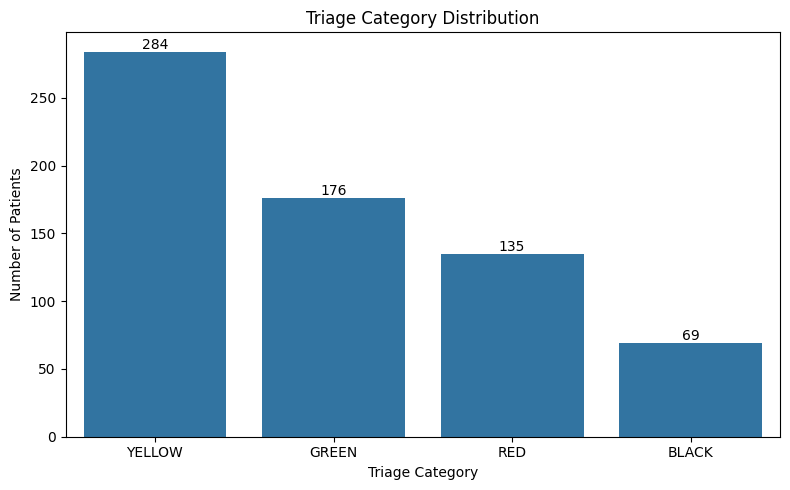

In [8]:
target_counts = train_df[TARGET].value_counts()

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": (target_counts / len(train_df) * 100).round(2)
})
display(target_summary)

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=train_df, x=TARGET, order=target_counts.index)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Triage Category Distribution")
plt.xlabel("Triage Category")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

Classes are imbalanced (YELLOW 42.8%, GREEN 26.5%, RED 20.3%, BLACK 10.4%), so
evaluation must track per-class metrics — especially RED and BLACK — not just overall
accuracy. Any train/validation split should be stratified to preserve these proportions.

## 6. Overall Missingness

Missing values in ED data are rarely random — a vital may be missing because a patient
couldn't be assessed, not because it wasn't recorded. Quantify missingness per feature
before deciding how to handle it.

,Missing Count,Missing %
pain_score,237,35.69
dbp,142,21.39
sbp,141,21.23
pain_assessable,140,21.08
o2sat,119,17.92
vs_sbp_min,83,12.50
vs_sbp_mean,83,12.50
vs_sbp_max,83,12.50
temperature,82,12.35
heartrate,80,12.05


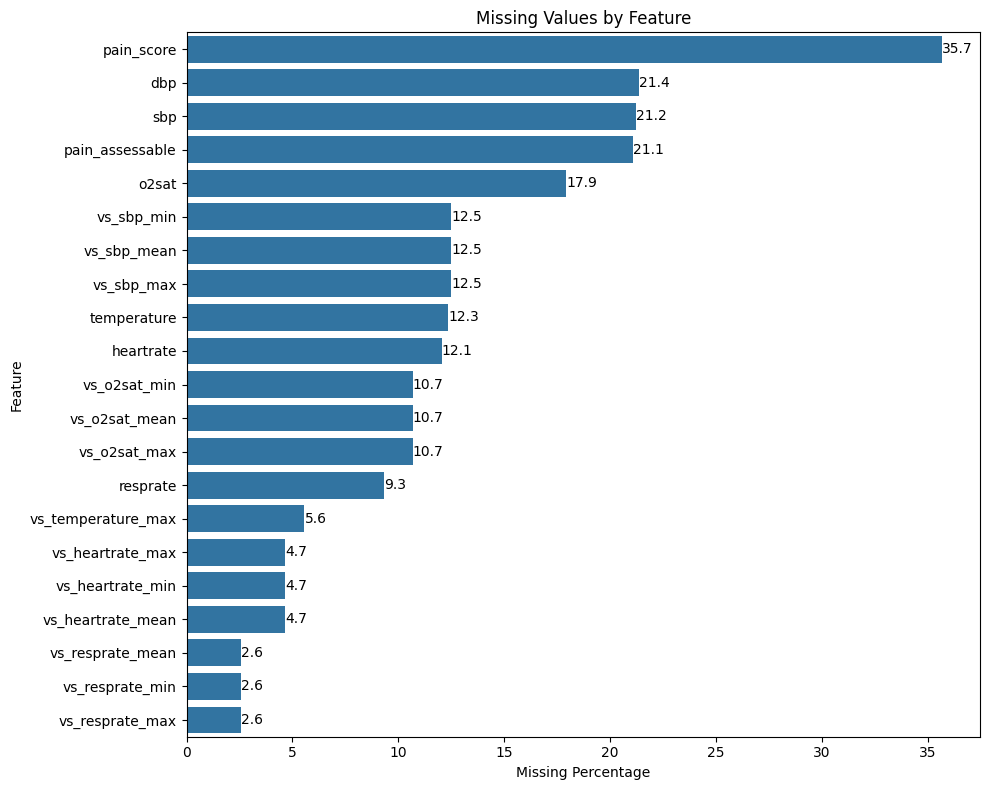

In [9]:
missing_summary = pd.DataFrame({
    "Missing Count": train_df.isna().sum(),
    "Missing %": (train_df.isna().mean() * 100).round(2)
}).sort_values("Missing %", ascending=False)

display(missing_summary)

missing_plot = missing_summary[missing_summary["Missing Count"] > 0]

plt.figure(figsize=(10, 8))
ax = sns.barplot(data=missing_plot.reset_index(), y="index", x="Missing %")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")
plt.title("Missing Values by Feature")
plt.xlabel("Missing Percentage")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Several vitals and GCS fields have substantial missingness. Whether a value is missing
may itself be informative (checked next) — the modeling pipeline will preserve that
signal explicitly rather than just filling gaps.

## 7. Missingness by Triage Category (MNAR Check)

If missingness rates differ sharply across triage categories, missing values are
informative (MNAR — missing not at random), not just noise to impute away.

start_category,BLACK,GREEN,RED,YELLOW
subject_id,0.00,0.00,0.00,0.00
gender,0.00,0.00,0.00,0.00
race,0.00,0.00,0.00,0.00
arrival_transport,0.00,0.00,0.00,0.00
temperature,27.54,9.09,15.56,9.15
heartrate,33.33,9.09,11.85,8.80
resprate,13.04,9.09,8.89,8.80
o2sat,76.81,9.09,18.52,8.80
sbp,98.55,9.09,23.70,8.80
dbp,98.55,9.09,23.70,9.15


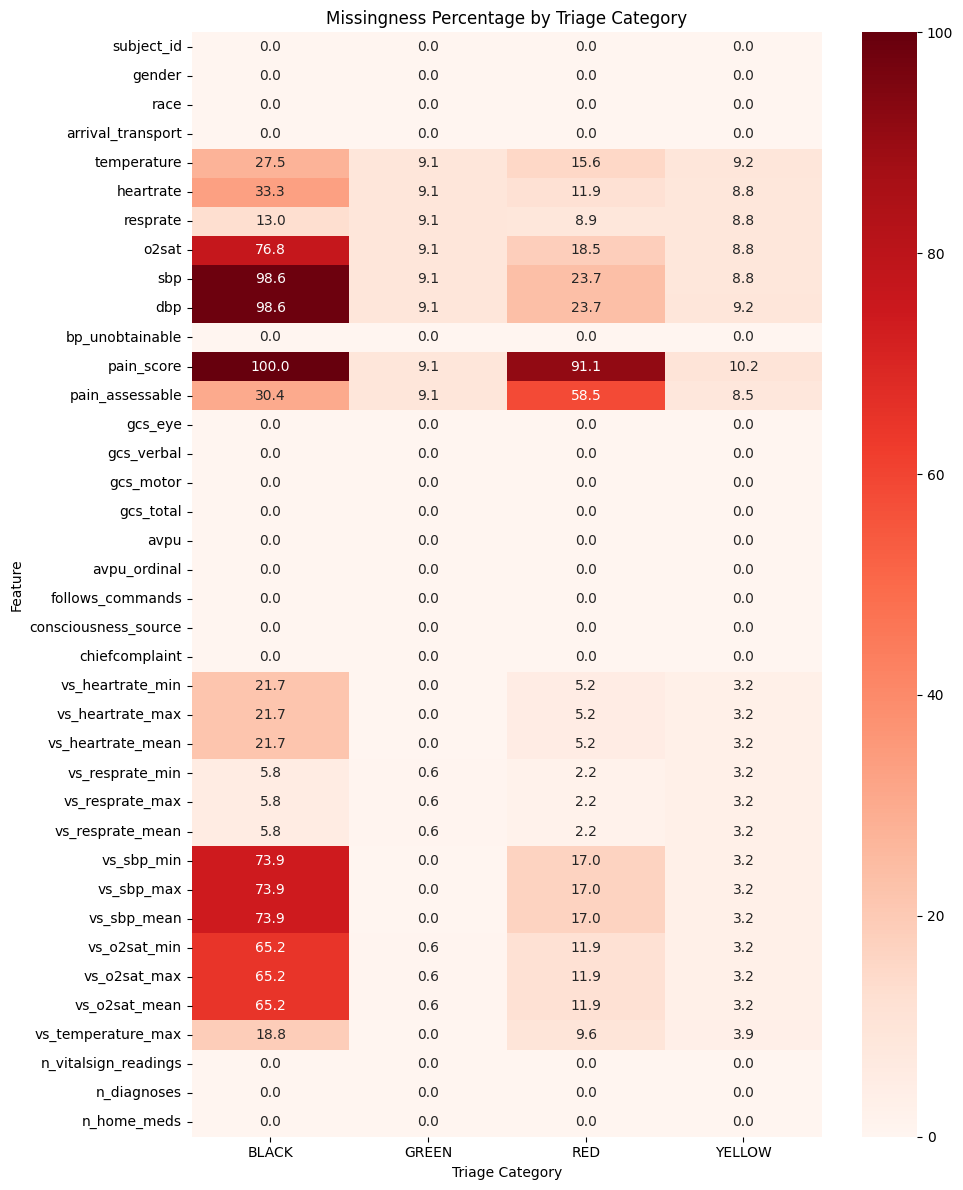

In [10]:
missing_by_class = (
    train_df
    .groupby(TARGET)
    .apply(lambda group: group.isna().mean() * 100, include_groups=False)
    .T
)
display(missing_by_class.round(2))

plt.figure(figsize=(10, 12))
sns.heatmap(missing_by_class, annot=True, fmt=".1f", cmap="Reds")
plt.title("Missingness Percentage by Triage Category")
plt.xlabel("Triage Category")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Finding:** `pain_score` is missing for 100% of BLACK and 91% of RED patients, but only
~10% of GREEN/YELLOW — critically ill or unresponsive patients simply can't report pain.
This is a severity signal, not noise, and will be preserved as explicit missingness flags
rather than imputed away.

## 8. Neurological Status — GCS

The Glasgow Coma Scale (`gcs_total`, plus `gcs_eye`/`gcs_verbal`/`gcs_motor`) measures
consciousness. Reduced consciousness should track with higher triage severity — check
whether it does.

In [11]:
gcs_summary = (
    train_df
    .groupby(TARGET)["gcs_total"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)
display(gcs_summary)

,count,mean,median,std,min,max
start_category,,,,,,
BLACK,69,3.00,3.0,0.00,3,3
GREEN,176,14.84,15.0,0.49,11,15
RED,135,9.56,12.0,4.92,3,15
YELLOW,284,14.62,15.0,0.85,9,15


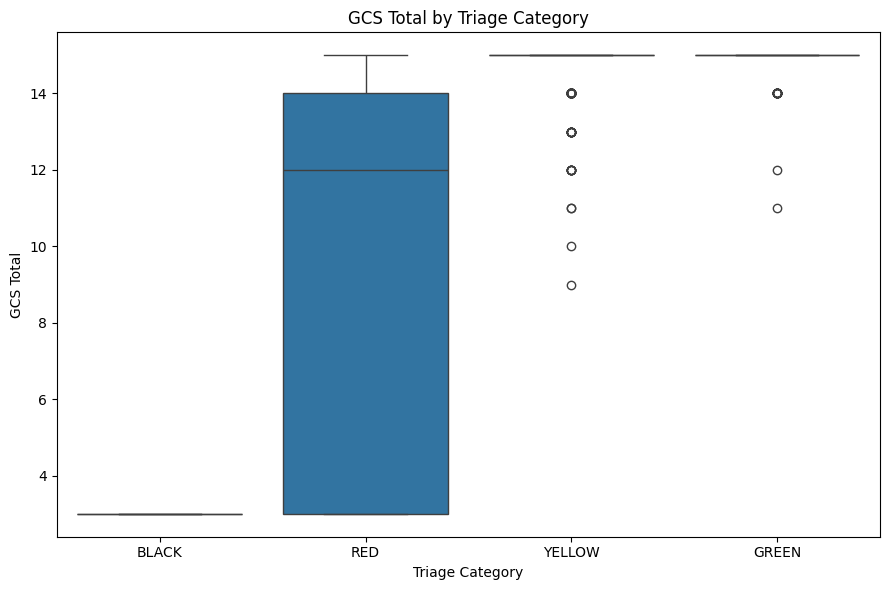

In [12]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=train_df, x=TARGET, y="gcs_total", order=["BLACK", "RED", "YELLOW", "GREEN"])
plt.title("GCS Total by Triage Category")
plt.xlabel("Triage Category")
plt.ylabel("GCS Total")
plt.tight_layout()
plt.show()

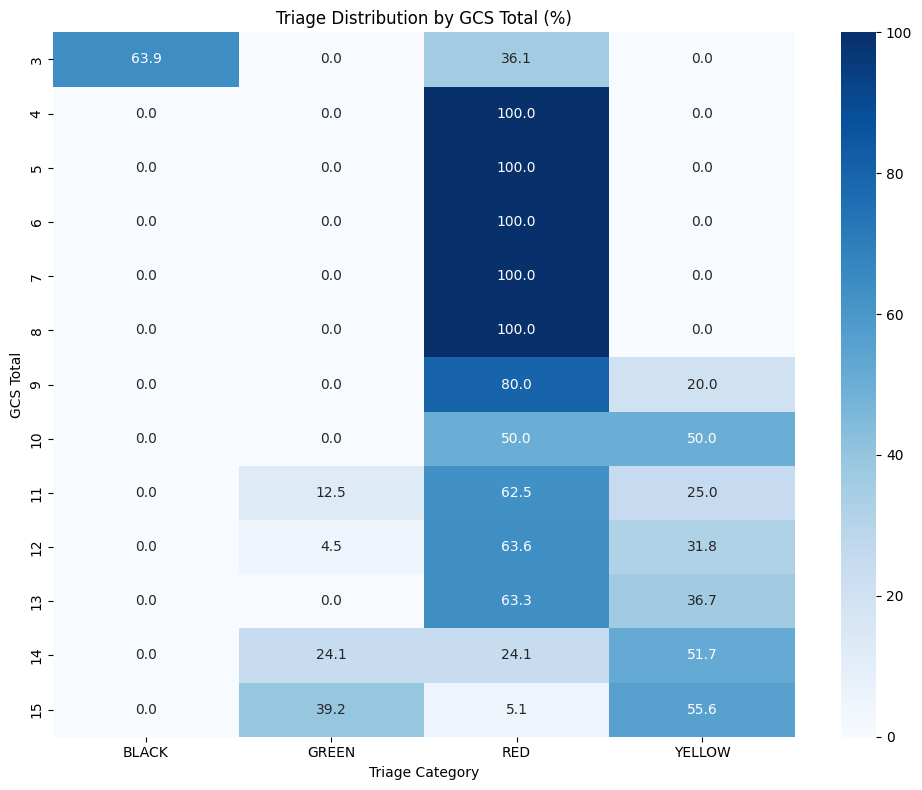

In [13]:
gcs_percentage = (
    pd.crosstab(train_df["gcs_total"], train_df[TARGET], normalize="index") * 100
)

plt.figure(figsize=(10, 8))
sns.heatmap(gcs_percentage, annot=True, fmt=".1f", cmap="Blues")
plt.title("Triage Distribution by GCS Total (%)")
plt.xlabel("Triage Category")
plt.ylabel("GCS Total")
plt.tight_layout()
plt.show()

Low GCS values are concentrated almost entirely in BLACK/RED, while higher scores are
dominated by YELLOW/GREEN — `gcs_total` is a strong predictor on its own.

## 9. AVPU, Follows Commands & Consciousness-Variable Collinearity

AVPU (`avpu`, `avpu_ordinal`) and `follows_commands` are two more consciousness measures.
Since all three overlap conceptually with GCS, check both their relationship with triage
and their correlation with each other.

AVPU values:


,count
avpu,
A,482
U,116
V,53
P,13


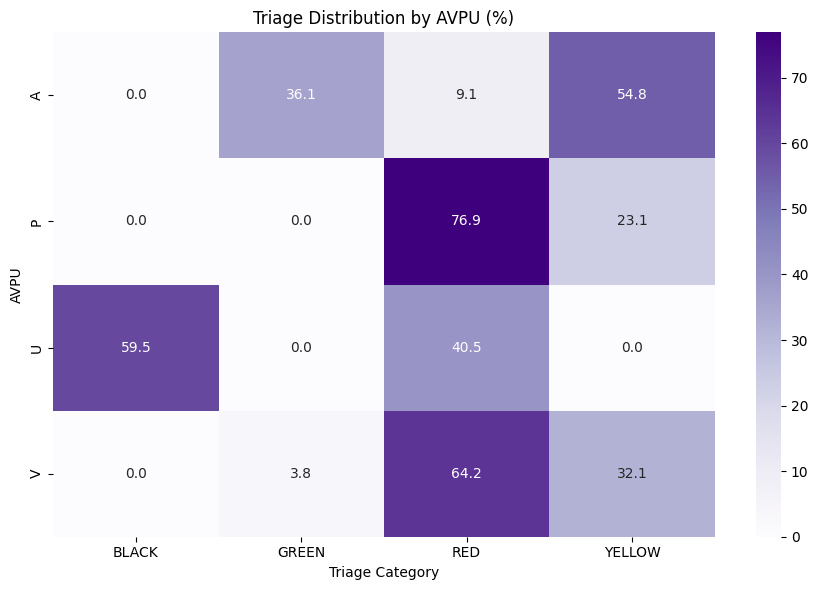

In [14]:
print("AVPU values:")
display(train_df["avpu"].value_counts(dropna=False))

avpu_percentage = pd.crosstab(train_df["avpu"], train_df[TARGET], normalize="index") * 100

plt.figure(figsize=(9, 6))
sns.heatmap(avpu_percentage, annot=True, fmt=".1f", cmap="Purples")
plt.title("Triage Distribution by AVPU (%)")
plt.xlabel("Triage Category")
plt.ylabel("AVPU")
plt.tight_layout()
plt.show()

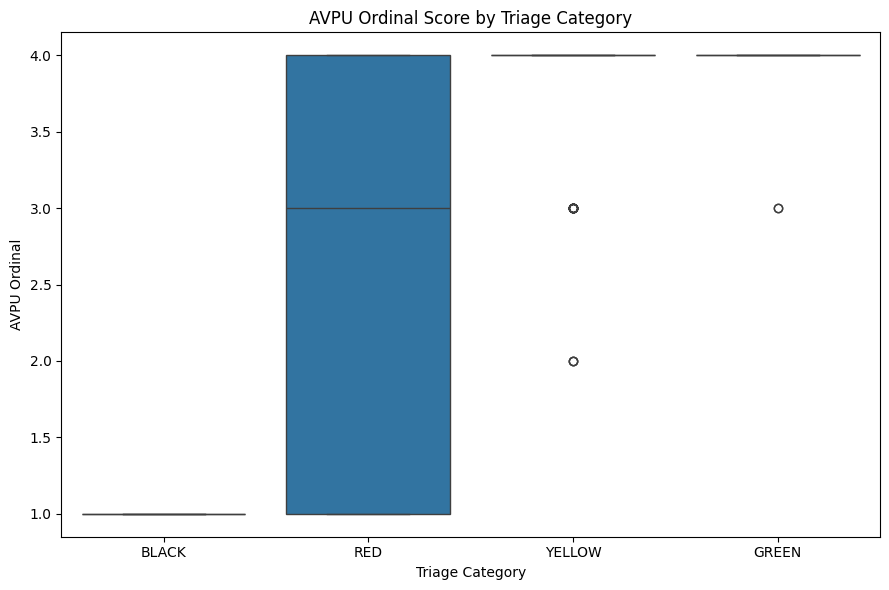

In [15]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=train_df, x=TARGET, y="avpu_ordinal", order=["BLACK", "RED", "YELLOW", "GREEN"])
plt.title("AVPU Ordinal Score by Triage Category")
plt.xlabel("Triage Category")
plt.ylabel("AVPU Ordinal")
plt.tight_layout()
plt.show()

start_category,BLACK,GREEN,RED,YELLOW
follows_commands,,,,
0,41.32,2.99,43.11,12.57
1,0.00,34.41,12.68,52.92


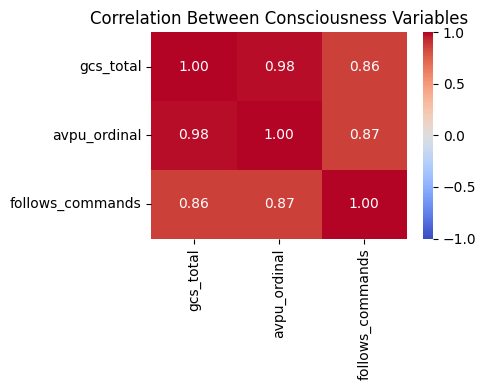

In [16]:
follows_percentage = (
    pd.crosstab(train_df["follows_commands"], train_df[TARGET], normalize="index") * 100
)
display(follows_percentage.round(2))

consciousness_corr = train_df[["gcs_total", "avpu_ordinal", "follows_commands"]].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(consciousness_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Consciousness Variables")
plt.tight_layout()
plt.show()

AVPU and `follows_commands` show the same pattern as GCS — low consciousness
concentrated in BLACK/RED. The correlation matrix confirms `gcs_total`, `avpu_ordinal`,
and `follows_commands` are highly collinear (r ≥ 0.86) — functionally near-duplicate
signals. All three are still kept for modeling (harmless for tree-based models), and a
single consolidated `flag_altered_consciousness` feature is added later for
interpretability.

## 10. Consciousness Assessment Source

`consciousness_source` records how the consciousness assessment was obtained — different
from the assessment itself. Check whether it varies by triage category or is just
clinical-workflow noise.

Consciousness Source:


,count
consciousness_source,
physiologic_baseline,401
documented_unresponsive,108
documented_no_loc,101
documented_coma_stupor,15
documented_intracranial_injury,11
documented_toxidrome,9
documented_altered_mental_status,8
documented_metabolic_derangement,6
documented_syncope,3


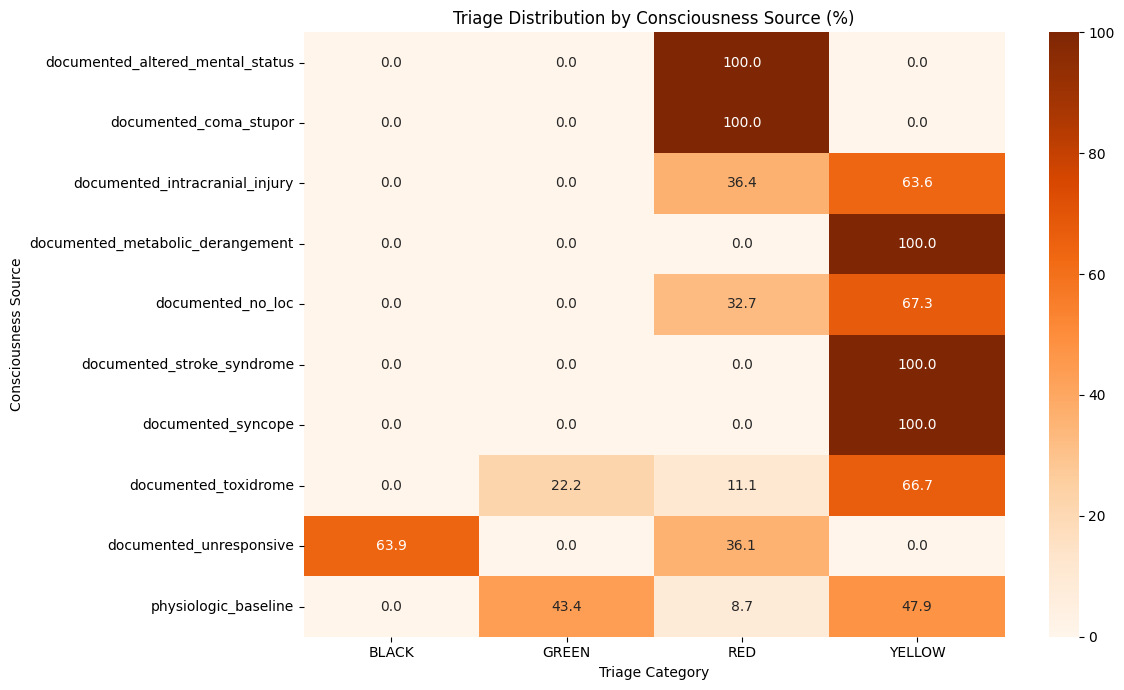

In [17]:
print("Consciousness Source:")
display(train_df["consciousness_source"].value_counts(dropna=False))

consciousness_percentage = (
    pd.crosstab(train_df["consciousness_source"], train_df[TARGET], normalize="index") * 100
)

plt.figure(figsize=(12, 7))
sns.heatmap(consciousness_percentage, annot=True, fmt=".1f", cmap="Oranges")
plt.title("Triage Distribution by Consciousness Source (%)")
plt.xlabel("Triage Category")
plt.ylabel("Consciousness Source")
plt.tight_layout()
plt.show()

Some sources skew toward higher-acuity categories, but several categories are rare — any
encoding of this feature needs to guard against overfitting on a 664-row dataset.

## 11. Chief Complaint Analysis

`chiefcomplaint` is free-text-like with many unique values — too sparse to one-hot
directly. Check cardinality and which complaints associate with which triage category, to
justify bucketing into clinical groups during feature engineering.

In [18]:
print("Number of unique chief complaints:", train_df["chiefcomplaint"].nunique())

print("\nTop 30 complaints:")
display(train_df["chiefcomplaint"].value_counts(dropna=False).head(30))

Number of unique chief complaints: 175

Top 30 complaints:


,count
chiefcomplaint,
HEADACHE,37
FALL,35
FRACTURE,34
ABD PAIN,32
CHEST PAIN,31
MINOR LACERATION,29
DIZZINESS,29
BACK PAIN,28
ANKLE INJURY,28


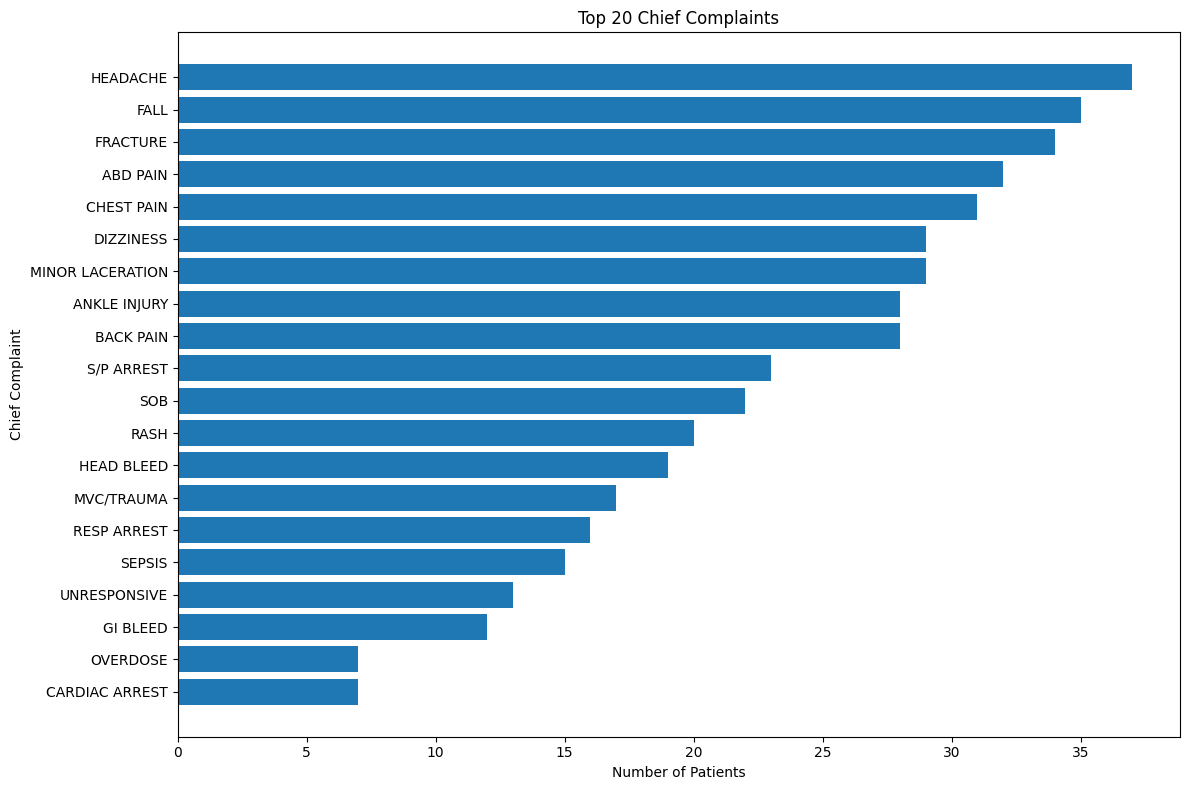

In [19]:
top_complaints = (
    train_df["chiefcomplaint"]
    .value_counts()
    .head(20)
    .sort_values()
)

plt.figure(figsize=(12, 8))
plt.barh(top_complaints.index.astype(str), top_complaints.values)
plt.title("Top 20 Chief Complaints")
plt.xlabel("Number of Patients")
plt.ylabel("Chief Complaint")
plt.tight_layout()
plt.show()

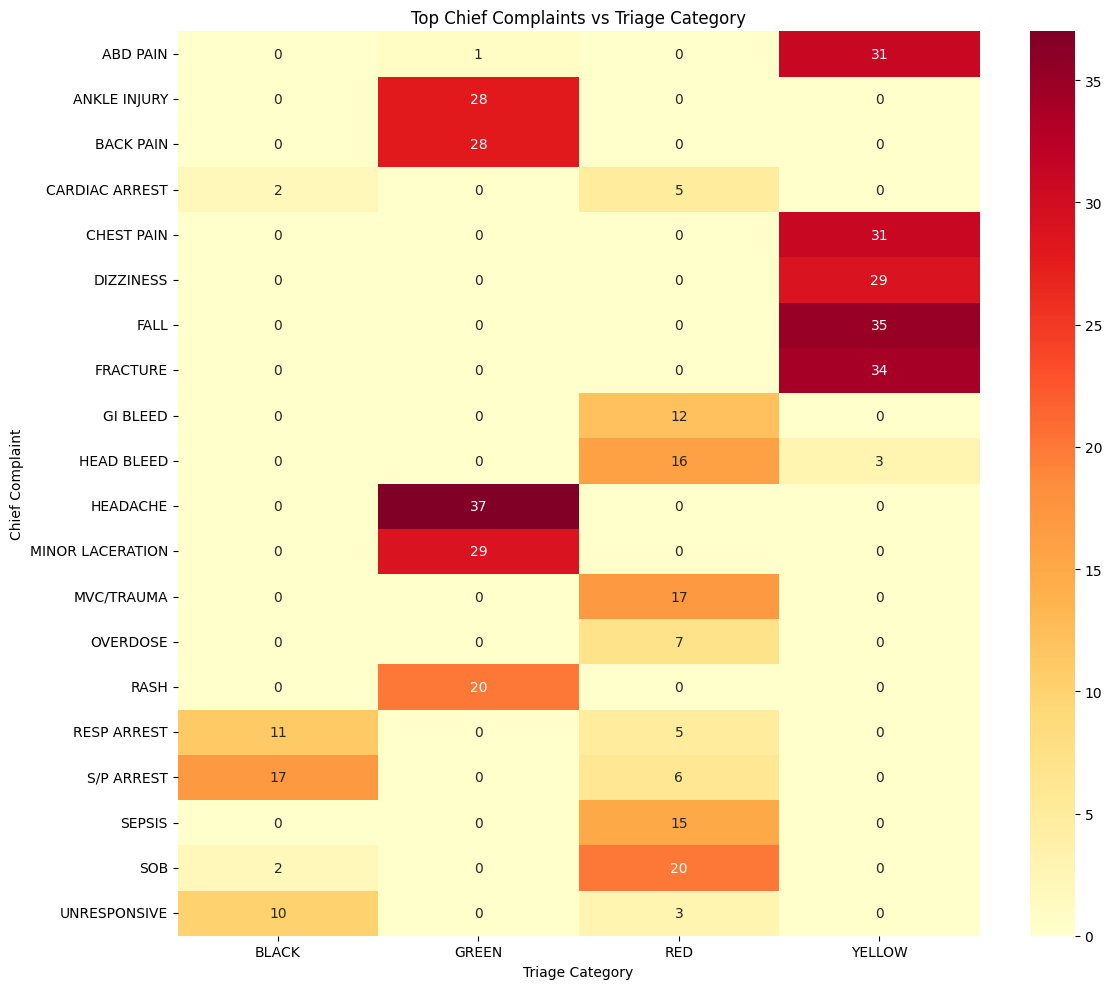

In [20]:
top_20_complaints = train_df["chiefcomplaint"].value_counts().head(20).index

complaint_class = pd.crosstab(train_df["chiefcomplaint"], train_df[TARGET])
complaint_class = complaint_class.loc[complaint_class.index.isin(top_20_complaints)]

plt.figure(figsize=(12, 10))
sns.heatmap(complaint_class, annot=True, fmt="d", cmap="YlOrRd")
plt.title("Top Chief Complaints vs Triage Category")
plt.xlabel("Triage Category")
plt.ylabel("Chief Complaint")
plt.tight_layout()
plt.show()

175 unique complaints across 664 rows is too sparse for direct one-hot encoding. The
heatmap shows complaints like arrest/unresponsive cluster in BLACK, while
respiratory/sepsis-type complaints skew RED — clinically coherent groups worth bucketing
into ~8 categories during feature engineering.

## 12. Vital Signs Analysis

Compare temperature, heart rate, respiratory rate, O2 saturation, and blood pressure
across triage categories to find which vitals separate classes.

In [21]:
vital_features = ["temperature", "heartrate", "resprate", "o2sat", "sbp", "dbp"]

vital_summary = (
    train_df
    .groupby(TARGET)[vital_features]
    .agg(["mean", "median", "std"])
    .round(2)
)
display(vital_summary)

temperature              heartrate               resprate  \
                      mean median   std      mean median    std     mean   
start_category                                                             
BLACK                94.43  94.45  2.51      5.93    0.0   8.48     0.23   
GREEN                98.20  98.20  0.74     86.02   84.5  13.13    17.30   
RED                  97.25  97.70  2.04    104.37  114.0  45.19    26.46   
YELLOW               98.22  98.20  0.74     95.23   97.0  16.61    20.49   

                              o2sat                   sbp                \
               median    std   mean median    std    mean median    std   
start_category                                                            
BLACK             0.0   0.77  45.12   45.0  15.24   51.00   51.0    NaN   
GREEN            17.0   2.25  97.19   97.0   1.87  122.91  120.0  16.96   
RED              30.0  12.54  79.66   83.0  14.50   84.13   79.0  26.03   
YELLOW           20.0   3.34  94.14   94.0   3.86  117.26  110.0  25.43   

                  dbp                
                 mean median    std  
start_category                       
BLACK           39.00   39.0    NaN  
GREEN           79.82   80.0  12.09  
RED             45.01   41.0  16.53  
YELLOW          68.11   68.0  13.98

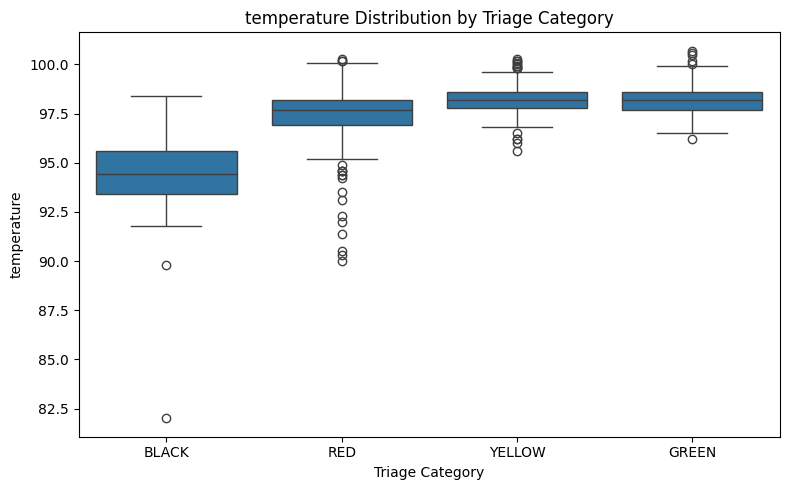

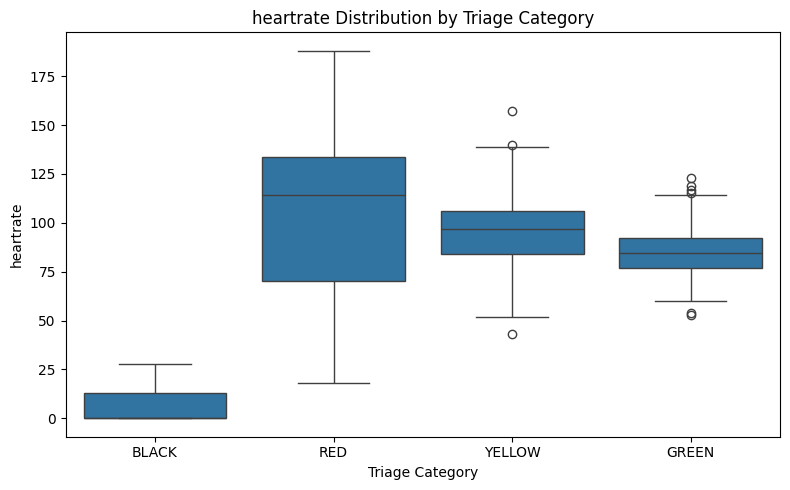

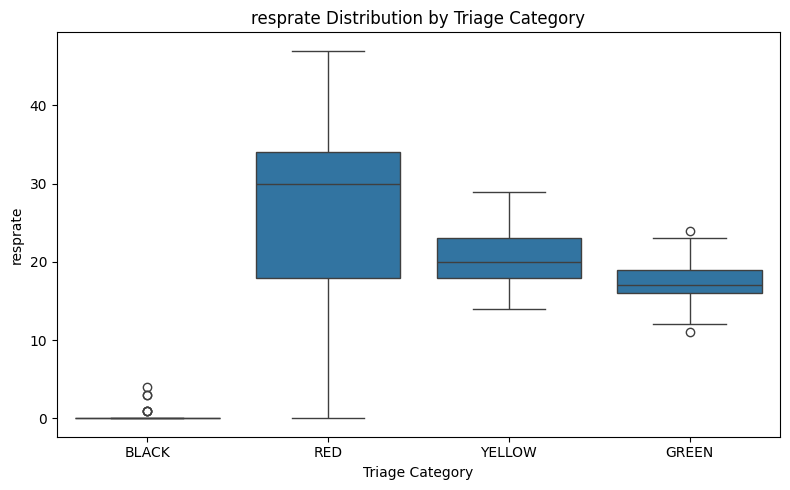

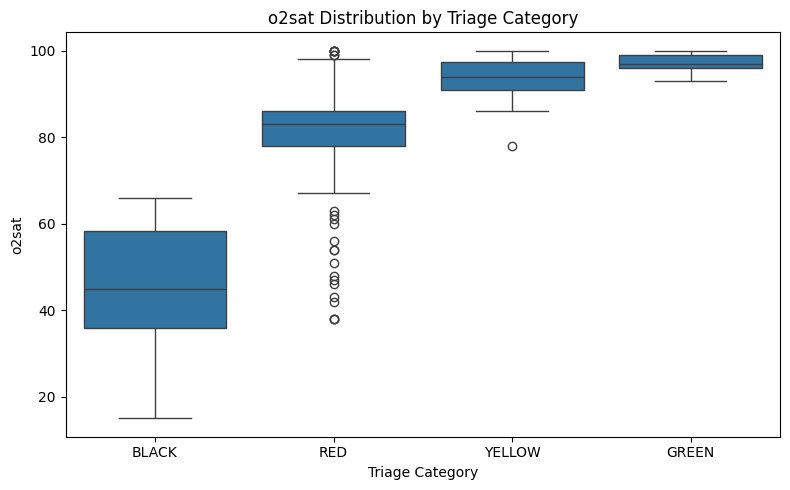

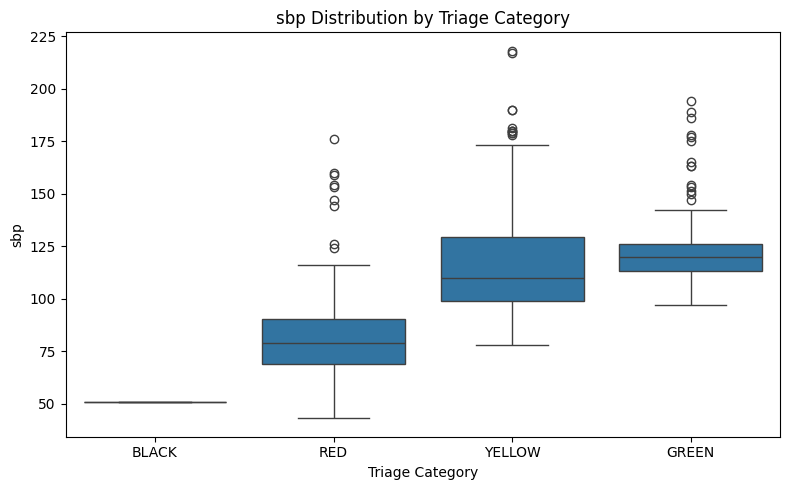

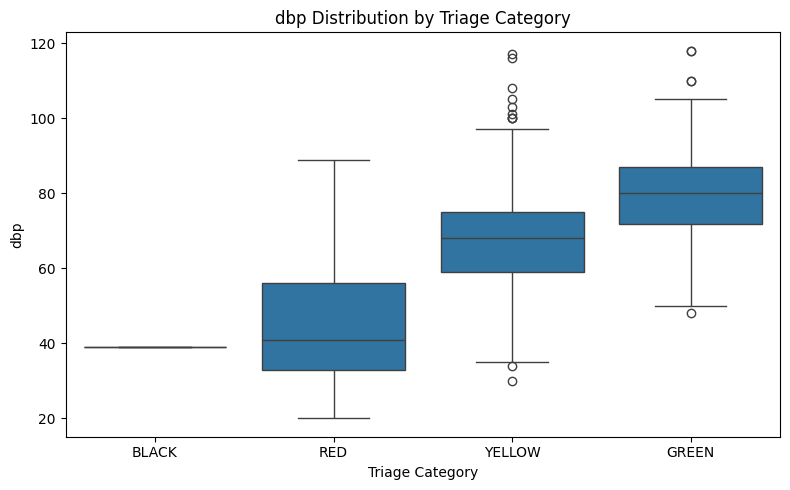

In [22]:
for feature in vital_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=train_df, x=TARGET, y=feature, order=["BLACK", "RED", "YELLOW", "GREEN"])
    plt.title(f"{feature} Distribution by Triage Category")
    plt.xlabel("Triage Category")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

Vitals show visible separation by triage category, but with heavy overlap and outliers —
consistent with clinical intuition that no single vital sign fully determines severity.
These differences motivate the clinical abnormality flags added in feature engineering,
rather than relying on raw vitals alone.

## 13. Arrival Transport

How a patient arrived at the ED is recorded in `arrival_transport`. Ambulance arrival is a
strong, legitimate severity signal — check its relationship with triage category, and
flag the risk that it could dominate feature importance and mask weaker signals.

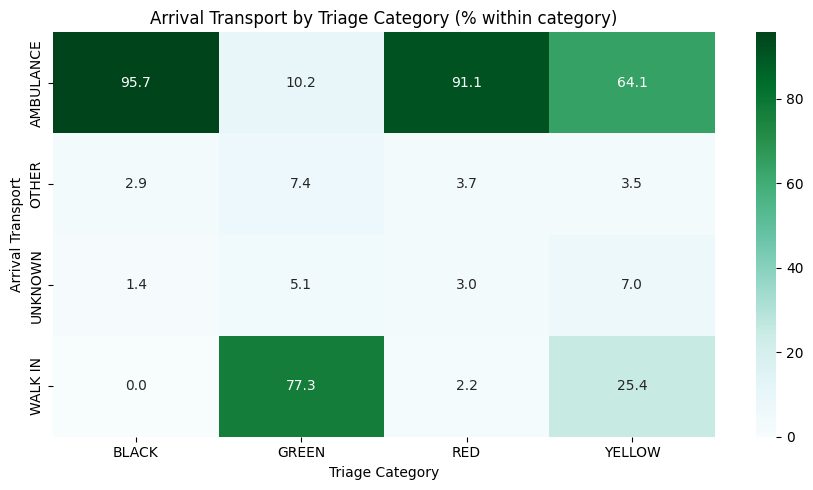

In [23]:
arrival_percentage = (
    pd.crosstab(train_df["arrival_transport"], train_df[TARGET], normalize="columns") * 100
)

plt.figure(figsize=(9, 5))
sns.heatmap(arrival_percentage, annot=True, fmt=".1f", cmap="BuGn")
plt.title("Arrival Transport by Triage Category (% within category)")
plt.xlabel("Triage Category")
plt.ylabel("Arrival Transport")
plt.tight_layout()
plt.show()

96% of BLACK and 91% of RED patients arrive by ambulance, vs. 77% of GREEN arriving as
walk-ins — `arrival_transport` is strongly predictive and clinically legitimate. It's
flagged here because a single dominant feature can mask weaker signals in feature
importance; this will be checked explicitly during interpretability (SHAP) later.

## 14. Investigating the BLACK Triage Category

`BLACK` shouldn't be assumed to mean any specific clinical outcome from the color label
alone. Check whether it has a distinct, learnable feature signature.

In [24]:
black_df = train_df[train_df[TARGET] == "BLACK"]

print("Number of BLACK patients:", len(black_df))

print("\n========== AVPU ==========")
display(black_df["avpu"].value_counts(dropna=False))

print("\n========== GCS ==========")
display(black_df["gcs_total"].value_counts(dropna=False).sort_index())

print("\n========== FOLLOWS COMMANDS ==========")
display(black_df["follows_commands"].value_counts(dropna=False))

print("\n========== CONSCIOUSNESS SOURCE ==========")
display(black_df["consciousness_source"].value_counts(dropna=False))

Number of BLACK patients: 69

========== AVPU ==========


,count
avpu,
U,69



========== GCS ==========


,count
gcs_total,
3,69



========== FOLLOWS COMMANDS ==========


,count
follows_commands,
0,69



========== CONSCIOUSNESS SOURCE ==========


,count
consciousness_source,
documented_unresponsive,69


In [25]:
is_black = train_df[TARGET] == "BLACK"

black_comparison_features = [
    "gcs_total", "avpu_ordinal", "follows_commands",
    "o2sat", "sbp", "dbp", "heartrate", "resprate"
]

black_comparison = (
    train_df[black_comparison_features]
    .groupby(is_black)
    .mean()
    .round(2)
)
display(black_comparison)

,gcs_total,avpu_ordinal,follows_commands,o2sat,sbp,dbp,heartrate,resprate
start_category,,,,,,,,
False,13.54,3.63,0.84,92.05,112.45,67.14,94.51,20.90
True,3.00,1.00,0.00,45.12,51.00,39.00,5.93,0.23


Every BLACK patient has `gcs_total == 3`, `avpu == 'U'`, and `follows_commands == 0`,
with `bp_unobtainable` true for 53/69 — a near-perfectly separable class with zero
exceptions in this data. This motivates a two-stage model: a simple BLACK vs. not-BLACK
classifier first, then a harder RED/YELLOW/GREEN classifier — RED is the genuinely
heterogeneous class (spans all AVPU states, ~47% follow commands).

## 15. EDA Summary and Modeling Implications

**Key findings:**
- `vs_*` columns are whole-encounter, not intake-only — problem reframed as severity
  re-assessment (Section 3).
- 30 repeat patients, 20 with a different triage category across visits — any split must
  group by `subject_id` (Section 4).
- Classes are imbalanced; BLACK is near-perfectly separable, RED is the hard class
  (Sections 5, 14).
- Missingness is MNAR, strongest for `pain_score`, and should be preserved as explicit
  flags rather than imputed (Sections 6–7).
- `gcs_total`, `avpu_ordinal`, `follows_commands` are highly collinear (r ≥ 0.86) but each
  still worth keeping (Section 9).
- `chiefcomplaint` needs bucketing (175 values); `arrival_transport` is strongly
  predictive but risks dominating feature importance (Sections 11, 13).

These findings drive the feature engineering and modeling choices below; every
transformation is still validated with cross-validation, not adopted on EDA intuition
alone.

## Phase 2: Handling Missing Values

### Step 1 — Create Missingness Flags

Before touching any actual values, create binary `_missing` columns (1 = was missing,
0 = was present) for every numeric vital and encounter field that has real gaps in the
training data.

**Why:** EDA showed missingness is MNAR (missing not at random) — e.g. `pain_score` is
missing for ~100% of BLACK patients and only ~10% of GREEN/YELLOW, because unresponsive
patients physically can't report pain. Flagging this explicitly lets the model use "this
was missing" as a feature in its own right, before deciding what to do with the value
underneath.

**Note:** Flags are only created for columns that actually have missing values in
`train_df`, so the feature set isn't cluttered with all-zero flags.

In [26]:
candidate_flag_cols = [
    'pain_score', 'sbp', 'dbp', 'o2sat', 'heartrate', 'resprate',
    'temperature', 'pain_assessable',
    'vs_heartrate_min', 'vs_heartrate_max', 'vs_heartrate_mean',
    'vs_resprate_min', 'vs_resprate_max', 'vs_resprate_mean',
    'vs_sbp_min', 'vs_sbp_max', 'vs_sbp_mean',
    'vs_o2sat_min', 'vs_o2sat_max', 'vs_o2sat_mean',
    'vs_temperature_max'
]

flagged_cols = []
for col in candidate_flag_cols:
    if col in train_df.columns and train_df[col].isna().sum() > 0:
        train_df[f'{col}_missing'] = train_df[col].isna().astype(int)
        if col in test_df.columns:
            test_df[f'{col}_missing'] = test_df[col].isna().astype(int)
        flagged_cols.append(col)

print(f"Created missingness flags for {len(flagged_cols)} columns: {flagged_cols}")

Created missingness flags for 21 columns: ['pain_score', 'sbp', 'dbp', 'o2sat', 'heartrate', 'resprate', 'temperature', 'pain_assessable', 'vs_heartrate_min', 'vs_heartrate_max', 'vs_heartrate_mean', 'vs_resprate_min', 'vs_resprate_max', 'vs_resprate_mean', 'vs_sbp_min', 'vs_sbp_max', 'vs_sbp_mean', 'vs_o2sat_min', 'vs_o2sat_max', 'vs_o2sat_mean', 'vs_temperature_max']


### Step 2 — Leave Numeric Gaps as Real NaN (No Imputation)

Vitals, GCS fields, `vs_*` encounter columns, and count fields are left with their
missing values intact — no median, mean, or other fill value is applied.

**Why:** A train-only median fill was considered and rejected — imputing `heartrate` for
a BLACK patient (true condition: no measurable pulse) with a global median (~95) would
erase the exact signal that makes BLACK separable. Since the data is MNAR, a single fill
value doesn't recover missing information — it manufactures misleading information.

**How this is handled downstream:** Tree-based models (LightGBM/XGBoost/CatBoost) split
on missingness natively, so passing real `NaN` through is simpler and more
information-preserving than any manual fill strategy.

In [27]:
numeric_cols_left_as_nan = [
    'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain_score',
    'vs_heartrate_min', 'vs_heartrate_max', 'vs_heartrate_mean',
    'vs_resprate_min', 'vs_resprate_max', 'vs_resprate_mean',
    'vs_sbp_min', 'vs_sbp_max', 'vs_sbp_mean',
    'vs_o2sat_min', 'vs_o2sat_max', 'vs_o2sat_mean',
    'vs_temperature_max', 'n_diagnoses', 'n_home_meds', 'n_vitalsign_readings',
    'gcs_eye', 'gcs_verbal', 'gcs_motor', 'gcs_total',
    'avpu_ordinal', 'follows_commands', 'bp_unobtainable', 'pain_assessable'
]

print("=== NaN counts left untouched (intentional — model handles natively) ===")
for col in numeric_cols_left_as_nan:
    if col in train_df.columns:
        n_missing = train_df[col].isna().sum()
        if n_missing > 0:
            print(f"{col}: {n_missing} missing ({n_missing/len(train_df):.1%})")

=== NaN counts left untouched (intentional — model handles natively) ===
temperature: 82 missing (12.3%)
heartrate: 80 missing (12.0%)
resprate: 62 missing (9.3%)
o2sat: 119 missing (17.9%)
sbp: 141 missing (21.2%)
dbp: 142 missing (21.4%)
pain_score: 237 missing (35.7%)
vs_heartrate_min: 31 missing (4.7%)
vs_heartrate_max: 31 missing (4.7%)
vs_heartrate_mean: 31 missing (4.7%)
vs_resprate_min: 17 missing (2.6%)
vs_resprate_max: 17 missing (2.6%)
vs_resprate_mean: 17 missing (2.6%)
vs_sbp_min: 83 missing (12.5%)
vs_sbp_max: 83 missing (12.5%)
vs_sbp_mean: 83 missing (12.5%)
vs_o2sat_min: 71 missing (10.7%)
vs_o2sat_max: 71 missing (10.7%)
vs_o2sat_mean: 71 missing (10.7%)
vs_temperature_max: 37 missing (5.6%)
pain_assessable: 140 missing (21.1%)


### Step 3 — Fill Categorical Columns with 'UNKNOWN'

For text/categorical columns (`gender`, `race`, `arrival_transport`, `avpu`,
`consciousness_source`, `chiefcomplaint`), missing values are filled with an explicit
`'UNKNOWN'` label rather than left as NaN or filled with the most common category.

**Why this differs from Step 2:** this isn't about MNAR bias — it's a practical
necessity, since most modeling libraries need string/category columns to hold an actual
value, not a raw blank. `'UNKNOWN'` instead of the majority class keeps this consistent
with Step 1's logic: missing documentation is itself often informative rather than
something to paper over.

In [28]:
# Categorical columns filled with an explicit 'UNKNOWN' label — a separate list from
# Section 2's dtype-derived categorical_cols, since this one is a fixed, hand-picked set.
categorical_fill_cols = ['gender', 'race', 'arrival_transport',
                          'avpu', 'consciousness_source', 'chiefcomplaint']

for col in categorical_fill_cols:
    if col in train_df.columns:
        train_df[col] = train_df[col].fillna('UNKNOWN')
    if col in test_df.columns:
        test_df[col] = test_df[col].fillna('UNKNOWN')

print(f"Filled categorical NaNs with 'UNKNOWN' for: {categorical_fill_cols}")

Filled categorical NaNs with 'UNKNOWN' for: ['gender', 'race', 'arrival_transport', 'avpu', 'consciousness_source', 'chiefcomplaint']


### Phase 2 Summary

- Missingness flags created for every numeric field with real gaps (signal preserved).
- Numeric vitals and encounter fields left as genuine `NaN` — no imputation, since the
  missingness pattern is MNAR and a fill value would distort the severity signal.
- Categorical fields given an explicit `'UNKNOWN'` label so no column is left with raw
  blanks going into modeling.

Nothing here is derived from `test_df` — the only thing happening is labeling what's
missing and leaving genuinely missing numbers as missing, ready for a model that handles
NaN natively.

**Next:** Phase 3 — feature engineering.

## Phase 3: Feature Engineering

### Step 1 — Vital Sign Abnormality Flags

Convert raw vitals into clinically standard abnormality flags (tachycardia, hypoxia,
hypotension, tachypnea, fever, etc.) using established medical thresholds.

**Why:** With only ~664 rows, the model shouldn't have to rediscover "heart rate > 100
matters" purely from raw numbers — encoding known clinical thresholds gives it a head
start.

**Rule:** If the source vital is missing, the flag is also left as `NaN` (not `0`) —
missing means "unknown," not "normal."

In [29]:
def add_vital_flags(df):
    df = df.copy()

    # Heart rate: normal ~60-100 bpm
    df['flag_tachycardic'] = np.where(df['heartrate'].isna(), np.nan, (df['heartrate'] > 100).astype(float))
    df['flag_bradycardic'] = np.where(df['heartrate'].isna(), np.nan, (df['heartrate'] < 60).astype(float))

    # O2 saturation: hypoxia below 92%
    df['flag_hypoxic'] = np.where(df['o2sat'].isna(), np.nan, (df['o2sat'] < 92).astype(float))

    # Systolic BP: hypotension below 90
    df['flag_hypotensive'] = np.where(df['sbp'].isna(), np.nan, (df['sbp'] < 90).astype(float))

    # Respiratory rate: normal ~12-20 breaths/min
    df['flag_tachypneic'] = np.where(df['resprate'].isna(), np.nan, (df['resprate'] > 20).astype(float))
    df['flag_bradypneic'] = np.where(df['resprate'].isna(), np.nan, (df['resprate'] < 12).astype(float))

    # Temperature (Fahrenheit): fever above 100.4, hypothermia below 95
    df['flag_fever'] = np.where(df['temperature'].isna(), np.nan, (df['temperature'] > 100.4).astype(float))
    df['flag_hypothermic'] = np.where(df['temperature'].isna(), np.nan, (df['temperature'] < 95).astype(float))

    return df

train_df = add_vital_flags(train_df)
test_df = add_vital_flags(test_df)

print("Added 8 vital abnormality flags")
print(train_df[[c for c in train_df.columns if c.startswith('flag_')]].mean())

Added 8 vital abnormality flags
flag_tachycardic    0.339041
flag_bradycardic    0.138699
flag_hypoxic        0.332110
flag_hypotensive    0.170172
flag_tachypneic     0.373754
flag_bradypneic     0.136213
flag_fever          0.005155
flag_hypothermic    0.072165
dtype: float64


### Step 2 — Vital Sign Instability (Range Features)

Compute the spread (max − min) for heart rate, respiratory rate, systolic BP, and O2 sat
across the encounter, using the `vs_*` columns kept in the leakage audit.

**Why:** A patient whose heart rate swung from 70 to 160 during their stay is clinically
very different from one who stayed steady at 90 — currently split across two separate
min/max columns. This feature surfaces instability as a single, explicit number.

**Note:** If either the min or max value is missing, the resulting range is `NaN` too —
this propagates naturally.

In [30]:
def add_vital_ranges(df):
    df = df.copy()

    vs_pairs = [
        ('vs_heartrate_min', 'vs_heartrate_max', 'vs_heartrate_range'),
        ('vs_resprate_min', 'vs_resprate_max', 'vs_resprate_range'),
        ('vs_sbp_min', 'vs_sbp_max', 'vs_sbp_range'),
        ('vs_o2sat_min', 'vs_o2sat_max', 'vs_o2sat_range'),
    ]

    for min_col, max_col, new_col in vs_pairs:
        if min_col in df.columns and max_col in df.columns:
            df[new_col] = df[max_col] - df[min_col]  # NaN propagates naturally if either side is missing

    return df

train_df = add_vital_ranges(train_df)
test_df = add_vital_ranges(test_df)

print("Added 4 vital instability range features")
print(train_df[['vs_heartrate_range', 'vs_resprate_range', 'vs_sbp_range', 'vs_o2sat_range']].describe())

Added 4 vital instability range features
       vs_heartrate_range  vs_resprate_range  vs_sbp_range  vs_o2sat_range
count          633.000000         647.000000    581.000000      593.000000
mean            19.262816           3.827468     18.754811        3.621190
std             22.608191           3.870246     15.959311        3.694083
min              0.000000           0.000000      0.000000        0.000000
25%              4.000000           1.000000      7.000000        1.000000
50%             14.000000           3.000000     16.000000        3.000000
75%             24.000000           6.000000     27.000000        5.000000
max            129.000000          26.000000    108.000000       38.000000


### Step 3 — Consolidated Consciousness Signal

Add one summary flag — `flag_altered_consciousness` — derived from `avpu` (1 if anything
other than "Alert", else 0).

**Why:** EDA showed `gcs_total`, `avpu_ordinal`, and `follows_commands` are almost the
same variable (r ≥ 0.86). Rather than dropping two of them, all three are kept for the
model and this one clean, human-readable flag is layered on top — it becomes the
headline feature for the interpretability story later.

In [31]:
def add_consciousness_flag(df):
    df = df.copy()
    # 'A' (Alert) on AVPU is the only fully normal state — anything else is altered consciousness
    df['flag_altered_consciousness'] = np.where(
        df['avpu'].isna(), np.nan,
        (df['avpu'] != 'A').astype(float)
    )
    return df

train_df = add_consciousness_flag(train_df)
test_df = add_consciousness_flag(test_df)

print("Added altered_consciousness flag")
print(train_df['flag_altered_consciousness'].value_counts(dropna=False))

Added altered_consciousness flag
flag_altered_consciousness
0.0    482
1.0    182
Name: count, dtype: int64


### Step 4 — Total Missingness Count

Sum every `_missing` flag column created in Phase 2 into a single `total_missing_count`
per patient.

**Why:** EDA confirmed missingness itself correlates with severity — e.g. BLACK patients
are missing nearly every vital (unresponsive patients can't be fully assessed). This
compresses that pattern, spread across a dozen flag columns, into one compact severity
proxy.

In [32]:
def add_missingness_count(df):
    df = df.copy()
    missing_flag_cols = [c for c in df.columns if c.endswith('_missing')]
    df['total_missing_count'] = df[missing_flag_cols].sum(axis=1)
    return df, missing_flag_cols

train_df, missing_flag_cols = add_missingness_count(train_df)
test_df, _ = add_missingness_count(test_df)

print(f"Summed {len(missing_flag_cols)} missingness flags into total_missing_count")
print(train_df['total_missing_count'].describe())

Summed 21 missingness flags into total_missing_count
count    664.000000
mean       2.478916
std        4.388334
min        0.000000
25%        0.000000
50%        0.000000
75%        2.000000
max       21.000000
Name: total_missing_count, dtype: float64


### Step 5 — Bucket `chiefcomplaint` into Clinical Categories

Group the 175 unique raw complaint strings into ~8 broad clinical categories
(ARREST_UNRESPONSIVE, CARDIAC, RESPIRATORY, TRAUMA, GI, NEURO, INFECTIOUS, PAIN_OTHER,
OTHER) using keyword matching.

**Why:** 175 unique values is too sparse to one-hot against only 664 rows — most
categories would have just a handful of examples. Bucketing preserves the signal EDA
found (e.g. "S/P ARREST" clustering in BLACK, "SOB"/"SEPSIS" in RED) while cutting
dimensionality drastically.

In [33]:
def bucket_complaint(complaint):
    if pd.isna(complaint):
        return 'UNKNOWN'
    c = str(complaint).upper()

    if any(k in c for k in ['ARREST', 'UNRESPONSIVE', 'FOUND DOWN', 'CODE']):
        return 'ARREST_UNRESPONSIVE'
    elif any(k in c for k in ['CHEST PAIN', 'CARDIAC', 'PALPITATION']):
        return 'CARDIAC'
    elif any(k in c for k in ['SOB', 'RESP', 'BREATH', 'COUGH']):
        return 'RESPIRATORY'
    elif any(k in c for k in ['TRAUMA', 'MVC', 'FALL', 'FRACTURE', 'INJURY', 'LACERATION']):
        return 'TRAUMA'
    elif any(k in c for k in ['BLEED', 'GI ', 'ABD PAIN', 'NAUSEA', 'VOMIT']):
        return 'GI'
    elif any(k in c for k in ['HEAD', 'DIZZ', 'SEIZURE', 'STROKE', 'WEAKNESS']):
        return 'NEURO'
    elif any(k in c for k in ['SEPSIS', 'FEVER', 'INFECTION']):
        return 'INFECTIOUS'
    elif any(k in c for k in ['PAIN', 'HEADACHE', 'BACK']):
        return 'PAIN_OTHER'
    else:
        return 'OTHER'

train_df['complaint_category'] = train_df['chiefcomplaint'].apply(bucket_complaint)
test_df['complaint_category'] = test_df['chiefcomplaint'].apply(bucket_complaint)

print("Complaint bucketing result:")
print(train_df['complaint_category'].value_counts())

Complaint bucketing result:
complaint_category
TRAUMA                 160
OTHER                  121
GI                      81
NEURO                   80
ARREST_UNRESPONSIVE     80
PAIN_OTHER              50
CARDIAC                 43
RESPIRATORY             30
INFECTIOUS              19
Name: count, dtype: int64


### Step 6 — Finalize Categorical Dtypes for Modeling

Convert all remaining string/object columns to pandas `category` dtype so
LightGBM/CatBoost can consume them natively, without manual one-hot encoding.

**Why:** Native categorical support plays correctly with the NaN-passthrough decision
from Phase 2, and avoids the dimensionality blow-up of one-hot encoding on a small
dataset.

**Caution:** Test-set categories are aligned to the categories seen in `train_df`. Any
category value in `test_df` that never appeared in `train_df` becomes `NaN` after this
step — the code checks for and flags this explicitly so it isn't missed silently.

In [34]:
categorical_cols_final = ['gender', 'race', 'arrival_transport', 'avpu',
                           'consciousness_source', 'complaint_category']

for col in categorical_cols_final:
    if col in train_df.columns:
        train_df[col] = train_df[col].astype('category')
    if col in test_df.columns:
        # align test categories to train's known categories — anything unseen becomes NaN, flagged below
        test_df[col] = pd.Categorical(test_df[col], categories=train_df[col].cat.categories)

# Check for unseen categories that got silently turned into NaN
for col in categorical_cols_final:
    if col in test_df.columns:
        if test_df[col].isna().sum() > 0:
            print(f"WARNING check needed — {col}: {test_df[col].isna().sum()} NaN in test after category alignment")

print("\nCategorical dtypes set:")
print(train_df[categorical_cols_final].dtypes)

WARNING check needed — consciousness_source: 1 NaN in test after category alignment

Categorical dtypes set:
gender                  category
race                    category
arrival_transport       category
avpu                    category
consciousness_source    category
complaint_category      category
dtype: object


### Phase 3 Summary

Starting from Phase 2's cleaned data (leakage-aware, NaN-preserving, categorically
labeled), this phase adds:

- 8 vital abnormality flags (clinical thresholds)
- 4 vital instability range features
- 1 consolidated consciousness flag
- 1 total-missingness count
- 1 bucketed complaint category (replacing the raw 175-value field)
- Finalized categorical dtypes ready for modeling

No feature uses the target column or any test-set-derived statistic — every threshold is
a fixed clinical constant, and the only thing "fit" on train (the category list in
Step 6) is applied to test without peeking at test's own values.

**Next:** Phase 4 — train/validation split (`StratifiedGroupKFold` grouped by
`subject_id`, per the patient-level leakage check in Section 4).

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# OFFICIAL CLASS ORDER
# ============================================================

CLASS_LABELS = ["RED", "YELLOW", "GREEN", "BLACK"]


# ============================================================
# OFFICIAL COST MATRIX
# Rows    = Actual
# Columns = Predicted
# ============================================================

COST_MATRIX = np.array([
    [0, 5, 10, 5],   # Actual RED
    [2, 0,  3, 2],   # Actual YELLOW
    [1, 1,  0, 1],   # Actual GREEN
    [2, 2,  2, 0]    # Actual BLACK
])


def evaluate_model(y_true, y_pred, model_name="Model"):

    print("=" * 70)
    print(f"EVALUATION: {model_name}")
    print("=" * 70)

    # --------------------------------------------------------
    # 1. Accuracy
    # --------------------------------------------------------

    accuracy = accuracy_score(y_true, y_pred)

    # --------------------------------------------------------
    # 2. Per-class Precision, Recall, F1
    # --------------------------------------------------------

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=CLASS_LABELS,
        zero_division=0
    )

    # --------------------------------------------------------
    # 3. Macro-F1
    # --------------------------------------------------------

    macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=CLASS_LABELS,
        average="macro",
        zero_division=0
    )

    # --------------------------------------------------------
    # 4. Weighted-F1
    # --------------------------------------------------------

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        labels=CLASS_LABELS,
        average="weighted",
        zero_division=0
    )

    # --------------------------------------------------------
    # 5. Confusion Matrix
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=CLASS_LABELS
    )

    # --------------------------------------------------------
    # 6. Total Misclassification Cost
    # --------------------------------------------------------

    total_cost = np.sum(cm * COST_MATRIX)

    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print(f"\nAccuracy    : {accuracy:.4f}")
    print(f"Macro-F1    : {macro_f1:.4f}")
    print(f"Weighted-F1 : {weighted_f1:.4f}")
    print(f"Total Cost  : {total_cost}")

    print("\nPer-Class Metrics:")

    metrics_df = pd.DataFrame({
        "Class": CLASS_LABELS,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Support": support
    })

    display(metrics_df.round(4))

    print("\nConfusion Matrix:")

    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual {c}" for c in CLASS_LABELS],
        columns=[f"Pred {c}" for c in CLASS_LABELS]
    )

    display(cm_df)

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "total_cost": total_cost,
        "precision": dict(zip(CLASS_LABELS, precision)),
        "recall": dict(zip(CLASS_LABELS, recall)),
        "f1": dict(zip(CLASS_LABELS, f1)),
        "confusion_matrix": cm
    }

In [36]:
from sklearn.model_selection import StratifiedGroupKFold

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

groups = train_df["subject_id"]

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Number of folds:", cv.get_n_splits())

Number of folds: 5


In [37]:
X_model = X.drop(columns=["subject_id"])

In [38]:
groups = train_df["subject_id"]

In [39]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Remove target and subject_id
X_model = train_df.drop(columns=[TARGET, "subject_id"])
y = train_df[TARGET]
groups = train_df["subject_id"]

# Identify categorical/numerical columns
cat_cols = X_model.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_model.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Categorical features:", len(cat_cols))
print("Numerical features:", len(num_cols))
print("Total features:", X_model.shape[1])

Categorical features: 7
Numerical features: 66
Total features: 73


In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median", add_indicator=True),
            num_cols
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1
                ))
            ]),
            cat_cols
        )
    ]
)

extra_trees = ExtraTreesClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", extra_trees)
])

In [41]:
oof_pred = np.empty(len(train_df), dtype=object)
oof_proba = np.zeros((len(train_df), len(CLASS_LABELS)))

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_model, y, groups=groups), 1
):

    X_train = X_model.iloc[train_idx]
    X_val = X_model.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model.fit(X_train, y_train)

    # Probability columns must follow CLASS_LABELS
    fold_proba = model.predict_proba(X_val)
    model_classes = model.named_steps["classifier"].classes_

    # Align probabilities explicitly
    aligned_proba = np.zeros((len(val_idx), len(CLASS_LABELS)))

    for i, cls in enumerate(model_classes):
        class_index = CLASS_LABELS.index(cls)
        aligned_proba[:, class_index] = fold_proba[:, i]

    oof_proba[val_idx] = aligned_proba

    oof_pred[val_idx] = np.array(CLASS_LABELS)[aligned_proba.argmax(axis=1)]

    print(f"Fold {fold} complete")

print("\nOOF predictions generated.")

Fold 1 complete
Fold 2 complete
Fold 3 complete
Fold 4 complete
Fold 5 complete

OOF predictions generated.


In [42]:
extra_trees_results = evaluate_model(
    y_true=y,
    y_pred=oof_pred,
    model_name="ExtraTrees"
)

EVALUATION: ExtraTrees

Accuracy    : 0.9036
Macro-F1    : 0.9114
Weighted-F1 : 0.9033
Total Cost  : 220

Per-Class Metrics:


,Class,Precision,Recall,F1-Score,Support
0,RED,0.9573,0.8296,0.8889,135
1,YELLOW,0.9068,0.8908,0.8988,284
2,GREEN,0.8564,0.9489,0.9003,176
3,BLACK,0.9315,0.9855,0.9577,69



Confusion Matrix:


,Pred RED,Pred YELLOW,Pred GREEN,Pred BLACK
Actual RED,112,17,1,5
Actual YELLOW,4,253,27,0
Actual GREEN,0,9,167,0
Actual BLACK,1,0,0,68


In [43]:
!pip -q install lightgbm

In [44]:
from lightgbm import LGBMClassifier

In [45]:
lightgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=20,
    max_depth=-1,
    min_child_samples=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", lightgbm_model)
])

In [46]:
lgb_oof_pred = np.empty(len(train_df), dtype=object)
lgb_oof_proba = np.zeros((len(train_df), len(CLASS_LABELS)))

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_model, y, groups=groups), 1
):

    X_train = X_model.iloc[train_idx]
    X_val = X_model.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    lgb_pipeline.fit(X_train, y_train)

    fold_proba = lgb_pipeline.predict_proba(X_val)
    model_classes = lgb_pipeline.named_steps["classifier"].classes_

    aligned_proba = np.zeros((len(val_idx), len(CLASS_LABELS)))

    for i, cls in enumerate(model_classes):
        class_index = CLASS_LABELS.index(cls)
        aligned_proba[:, class_index] = fold_proba[:, i]

    lgb_oof_proba[val_idx] = aligned_proba

    lgb_oof_pred[val_idx] = np.array(
        CLASS_LABELS
    )[aligned_proba.argmax(axis=1)]

    print(f"Fold {fold} complete")

print("\nLightGBM OOF predictions generated.")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1 complete


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2 complete


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 3 complete


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4 complete
Fold 5 complete

LightGBM OOF predictions generated.


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [47]:
lgb_oof_pred = np.empty(len(train_df), dtype=object)
lgb_oof_proba = np.zeros((len(train_df), len(CLASS_LABELS)))

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_model, y, groups=groups), 1
):

    X_train = X_model.iloc[train_idx]
    X_val = X_model.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    lgb_pipeline.fit(X_train, y_train)

    fold_proba = lgb_pipeline.predict_proba(X_val)
    model_classes = lgb_pipeline.named_steps["classifier"].classes_

    aligned_proba = np.zeros((len(val_idx), len(CLASS_LABELS)))

    for i, cls in enumerate(model_classes):
        class_index = CLASS_LABELS.index(cls)
        aligned_proba[:, class_index] = fold_proba[:, i]

    lgb_oof_proba[val_idx] = aligned_proba

    lgb_oof_pred[val_idx] = np.array(
        CLASS_LABELS
    )[aligned_proba.argmax(axis=1)]

    print(f"Fold {fold} complete")

print("\nLightGBM OOF predictions generated.")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1 complete


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2 complete


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 3 complete


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4 complete
Fold 5 complete

LightGBM OOF predictions generated.


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [48]:
lgb_results = evaluate_model(
    y_true=y,
    y_pred=lgb_oof_pred,
    model_name="LightGBM"
)

EVALUATION: LightGBM

Accuracy    : 0.9292
Macro-F1    : 0.9359
Weighted-F1 : 0.9290
Total Cost  : 158

Per-Class Metrics:


,Class,Precision,Recall,F1-Score,Support
0,RED,0.9752,0.8741,0.9219,135
1,YELLOW,0.9288,0.9190,0.9239,284
2,GREEN,0.8942,0.9602,0.9260,176
3,BLACK,0.9452,1.0000,0.9718,69



Confusion Matrix:


,Pred RED,Pred YELLOW,Pred GREEN,Pred BLACK
Actual RED,118,13,0,4
Actual YELLOW,3,261,20,0
Actual GREEN,0,7,169,0
Actual BLACK,0,0,0,69


In [49]:
# ============================================================
# FINAL SUBMISSION CSV
# ============================================================

# Features used for final training
X_full = train_df.drop(columns=[TARGET, "subject_id"])
y_full = train_df[TARGET]

# Test features
X_test = test_df.drop(columns=["subject_id"])

# ------------------------------------------------------------
# Train final model on ALL training data
# ------------------------------------------------------------

model.fit(X_full, y_full)

print("Final model trained on full training dataset.")

# ------------------------------------------------------------
# Predict test probabilities
# ------------------------------------------------------------

test_proba_raw = model.predict_proba(X_test)

model_classes = model.named_steps["classifier"].classes_

# Align probabilities to official class order
test_proba = np.zeros(
    (len(test_df), len(CLASS_LABELS))
)

for i, cls in enumerate(model_classes):
    class_index = CLASS_LABELS.index(cls)
    test_proba[:, class_index] = test_proba_raw[:, i]

# ------------------------------------------------------------
# Predicted triage
# ------------------------------------------------------------

test_pred = np.array(
    CLASS_LABELS
)[test_proba.argmax(axis=1)]

# ------------------------------------------------------------
# Create submission dataframe
# ------------------------------------------------------------

submission = pd.DataFrame({
    "Patient ID": test_df["subject_id"],
    "Predicted Triage": test_pred,
    "RED Probability": test_proba[:, 0],
    "YELLOW Probability": test_proba[:, 1],
    "GREEN Probability": test_proba[:, 2],
    "BLACK Probability": test_proba[:, 3]
})

# ------------------------------------------------------------
# Round probabilities
# ------------------------------------------------------------

submission[
    [
        "RED Probability",
        "YELLOW Probability",
        "GREEN Probability",
        "BLACK Probability"
    ]
] = submission[
    [
        "RED Probability",
        "YELLOW Probability",
        "GREEN Probability",
        "BLACK Probability"
    ]
].round(6)

# ------------------------------------------------------------
# Verify probability sums
# ------------------------------------------------------------

prob_cols = [
    "RED Probability",
    "YELLOW Probability",
    "GREEN Probability",
    "BLACK Probability"
]

prob_sums = submission[prob_cols].sum(axis=1)

print("Maximum probability-sum error:",
      np.abs(prob_sums - 1).max())

# ------------------------------------------------------------
# Verify row count and columns
# ------------------------------------------------------------

print("\nSubmission shape:", submission.shape)

print("\nColumns:")
print(submission.columns.tolist())

print("\nFirst 10 predictions:")
display(submission.head(10))

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

TEAM_ID = "YOUR_TEAM_ID"

output_filename = f"{TEAM_ID}_MM26ML03.csv"

submission.to_csv(
    output_filename,
    index=False
)

print(f"\nSubmission saved as: {output_filename}")

Final model trained on full training dataset.
Maximum probability-sum error: 1.000000000139778e-06

Submission shape: (112, 6)

Columns:
['Patient ID', 'Predicted Triage', 'RED Probability', 'YELLOW Probability', 'GREEN Probability', 'BLACK Probability']

First 10 predictions:


,Patient ID,Predicted Triage,RED Probability,YELLOW Probability,GREEN Probability,BLACK Probability
0,90000431,BLACK,0.202153,0.006376,0.001182,0.790290
1,90000438,BLACK,0.021588,0.000688,0.000412,0.977313
2,90000445,BLACK,0.029245,0.000601,0.000000,0.970155
3,90000457,BLACK,0.005320,0.000000,0.000000,0.994680
4,90000460,BLACK,0.043693,0.000000,0.000000,0.956307
5,90000461,BLACK,0.004913,0.000000,0.000000,0.995087
6,90000481,BLACK,0.005536,0.000000,0.000000,0.994464
7,90000489,BLACK,0.009319,0.000000,0.000000,0.990681
8,90000501,BLACK,0.009875,0.000000,0.000000,0.990125
9,90000502,BLACK,0.008747,0.000000,0.000000,0.991253



Submission saved as: YOUR_TEAM_ID_MM26ML03.csv
